
# Modelos N-gram: Tutorial Prático (PT-BR)

Este notebook apresenta **modelos de N-gram** (unigrama, bigrama e trigrama) aplicados a um corpus simples em português.
Você aprenderá a:
- Tokenizar e construir contagens de N-gramas
- Calcular probabilidades com **suavização de Laplace**
- **Prever** a próxima palavra
- **Gerar texto** com modelos de N-gram
- Calcular **probabilidade** de sentenças e **perplexidade**
- Visualizar N-gramas mais frequentes

> Dica: use este notebook como base para aulas e experimentos rápidos.


In [1]:

# Imports essenciais
from collections import Counter, defaultdict
import math
import random
import re

# Visualização (use apenas matplotlib, sem estilos ou cores explícitas, por diretriz)
import matplotlib.pyplot as plt

# ---------------------------
# Utilidades de tokenização
# ---------------------------
def simple_tokenize(text):
    '''
    Tokenizador simples para PT-BR:
    - Minúsculas
    - Espaços e pontuação básica
    - Remove múltiplos espaços
    '''
    text = text.lower()
    text = re.sub(r"[^a-záéíóúàâêôãõç0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def sent_tokenize(paragraph):
    '''
    Segmenta por pontuação básica em frases.
    '''
    # Mantém delimitadores para uma segmentação simples
    raw_sentences = re.split(r"[.!?]+", paragraph)
    sentences = [s.strip() for s in raw_sentences if s.strip()]
    return sentences

# ---------------------------
# Corpus de exemplo (PT-BR)
# ---------------------------
corpus_raw = [
    "O gato preto dorme no sofá. O cachorro marrom late no quintal.",
    "A gata branca observa o pássaro na janela.",
    "O cachorro corre atrás da bola no parque.",
    "O gato dorme e sonha com sardinhas.",
    "A criança brinca com o cachorro e o gato no jardim.",
    "O pássaro canta pela manhã enquanto o gato observa.",
    "O cachorro dorme depois da corrida no parque.",
]

# Constrói lista de sentenças tokenizadas com <s> e </s>
def build_dataset(raw_docs):
    sentences_tok = []
    for doc in raw_docs:
        for s in sent_tokenize(doc):
            toks = simple_tokenize(s)
            if toks:
                sentences_tok.append(["<s>"] + toks + ["</s>"])
    return sentences_tok

sentences = build_dataset(corpus_raw)
len(sentences), sentences[:3]


(8,
 [['<s>', 'o', 'gato', 'preto', 'dorme', 'no', 'sofá', '</s>'],
  ['<s>', 'o', 'cachorro', 'marrom', 'late', 'no', 'quintal', '</s>'],
  ['<s>',
   'a',
   'gata',
   'branca',
   'observa',
   'o',
   'pássaro',
   'na',
   'janela',
   '</s>']])


## 1) Construindo contagens de N-gramas

Vamos extrair unigramas, bigramas e trigramas do corpus tokenizado.
Incluímos os marcadores **`<s>`** (início) e **`</s>`** (fim) para melhorar o modelamento de início e término de frases.


In [2]:

def ngrams_from_sentence(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def build_ngram_counts(sentences, n):
    counts = Counter()
    for s in sentences:
        counts.update(ngrams_from_sentence(s, n))
    return counts

unigram_counts = build_ngram_counts(sentences, 1)
bigram_counts = build_ngram_counts(sentences, 2)
trigram_counts = build_ngram_counts(sentences, 3)

# Vocabulário (inclui <s> e </s> para simplificar)
vocab = set([w for (w,) in unigram_counts.keys()])
V = len(vocab)

print("Tamanho do vocabulário:", V)
print("Top 10 unigramas:", unigram_counts.most_common(10))
print("Top 10 bigramas:", bigram_counts.most_common(10))
print("Top 10 trigramas:", trigram_counts.most_common(10))


Tamanho do vocabulário: 37
Top 10 unigramas: [(('o',), 10), (('<s>',), 8), (('</s>',), 8), (('no',), 5), (('gato',), 4), (('cachorro',), 4), (('dorme',), 3), (('a',), 2), (('observa',), 2), (('pássaro',), 2)]
Top 10 bigramas: [(('<s>', 'o'), 6), (('o', 'gato'), 4), (('o', 'cachorro'), 4), (('<s>', 'a'), 2), (('o', 'pássaro'), 2), (('no', 'parque'), 2), (('parque', '</s>'), 2), (('gato', 'preto'), 1), (('preto', 'dorme'), 1), (('dorme', 'no'), 1)]
Top 10 trigramas: [(('<s>', 'o', 'cachorro'), 3), (('<s>', 'o', 'gato'), 2), (('no', 'parque', '</s>'), 2), (('o', 'gato', 'preto'), 1), (('gato', 'preto', 'dorme'), 1), (('preto', 'dorme', 'no'), 1), (('dorme', 'no', 'sofá'), 1), (('no', 'sofá', '</s>'), 1), (('o', 'cachorro', 'marrom'), 1), (('cachorro', 'marrom', 'late'), 1)]



## 2) Probabilidades com Suavização de Laplace

Sem suavização, N-gramas não observados têm probabilidade 0.  
A **Laplace (add-one)** evita zeros somando 1 às contagens:

$$
P_{\text{Laplace}}(w_i \mid h) = \frac{ \text{count}(h, w_i) + 1 }{ \sum_{w} \text{count}(h, w) + V }
$$

onde \(h\) é o histórico (por ex., a palavra anterior no bigrama, ou as duas anteriores no trigrama) e \(V\) é o tamanho do vocabulário.


In [3]:

# Índices de conveniência
def context_counts(counts):
    '''
    Retorna dicionário: contexto -> soma das contagens das saídas possíveis
    Para bigramas: contexto é a 1a palavra
    Para trigramas: contexto são as 2 palavras anteriores
    '''
    total_by_ctx = defaultdict(int)
    for ng, c in counts.items():
        ctx = ng[:-1]
        total_by_ctx[ctx] += c
    return total_by_ctx

bigram_totals_by_ctx = context_counts(bigram_counts)
trigram_totals_by_ctx = context_counts(trigram_counts)

def prob_bigram_laplace(w_prev, w_curr, bigram_counts, totals_by_ctx, V):
    return (bigram_counts.get((w_prev, w_curr), 0) + 1) / (totals_by_ctx.get((w_prev,), 0) + V)

def prob_trigram_laplace(w_prev2, w_prev1, w_curr, trigram_counts, totals_by_ctx, V):
    return (trigram_counts.get((w_prev2, w_prev1, w_curr), 0) + 1) / (totals_by_ctx.get((w_prev2, w_prev1), 0) + V)

# Teste rápido de probabilidades
print("P(dorme | gato) (Laplace, bigrama):", prob_bigram_laplace("gato", "dorme", bigram_counts, bigram_totals_by_ctx, V))
print("P(dorme | o, gato) (Laplace, trigrama):", prob_trigram_laplace("o", "gato", "dorme", trigram_counts, trigram_totals_by_ctx, V))


P(dorme | gato) (Laplace, bigrama): 0.04878048780487805
P(dorme | o, gato) (Laplace, trigrama): 0.04878048780487805



## 3) Predição da Próxima Palavra

Dada uma palavra (bigrama) ou duas palavras (trigrama), escolhemos a próxima com maior probabilidade (Laplace).


In [4]:

def next_word_bigram(context_word, vocab, bigram_counts, totals_by_ctx, V, topk=5):
    candidates = []
    for w in vocab:
        p = prob_bigram_laplace(context_word, w, bigram_counts, totals_by_ctx, V)
        candidates.append((w, p))
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[:topk]

def next_word_trigram(ctx2, ctx1, vocab, trigram_counts, totals_by_ctx, V, topk=5):
    candidates = []
    for w in vocab:
        p = prob_trigram_laplace(ctx2, ctx1, w, trigram_counts, totals_by_ctx, V)
        candidates.append((w, p))
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[:topk]

print("Top próximas palavras para contexto (gato) [bigrama]:")
print(next_word_bigram("gato", vocab, bigram_counts, bigram_totals_by_ctx, V))

print("\nTop próximas palavras para contexto (o, gato) [trigrama]:")
print(next_word_trigram("o", "gato", vocab, trigram_counts, trigram_totals_by_ctx, V))


Top próximas palavras para contexto (gato) [bigrama]:
[('dorme', 0.04878048780487805), ('no', 0.04878048780487805), ('observa', 0.04878048780487805), ('preto', 0.04878048780487805), ('na', 0.024390243902439025)]

Top próximas palavras para contexto (o, gato) [trigrama]:
[('dorme', 0.04878048780487805), ('no', 0.04878048780487805), ('observa', 0.04878048780487805), ('preto', 0.04878048780487805), ('na', 0.024390243902439025)]



## 4) Probabilidade de Sentença e Perplexidade

Para uma sentença \(w_1,\dots,w_T\), com bigramas:

$$
P(w_1,\dots,w_T) \approx \prod_{t=2}^{T} P(w_t \mid w_{t-1})
$$

A **perplexidade** é:

$$
\text{PP}(W) = P(W)^{-\frac{1}{T}} = 2^{-\frac{1}{T}\sum_{t=1}^T \log_2 P(w_t \mid \text{contexto})}
$$


In [5]:

def sentence_logprob_bigram(tokens, bigram_counts, totals_by_ctx, V):
    # Usa Laplace para evitar log(0)
    logp = 0.0
    for i in range(1, len(tokens)):
        p = prob_bigram_laplace(tokens[i-1], tokens[i], bigram_counts, totals_by_ctx, V)
        logp += math.log2(p)
    return logp

def perplexity_bigram(tokens, bigram_counts, totals_by_ctx, V):
    T = len(tokens)
    logp = sentence_logprob_bigram(tokens, bigram_counts, totals_by_ctx, V)
    return 2 ** ( - (logp / T) )

# Exemplo
test_sent = ["<s>", "o", "gato", "dorme", "</s>"]
pp = perplexity_bigram(test_sent, bigram_counts, bigram_totals_by_ctx, V)
pp


8.689829110853772


## 5) Geração de Texto (Amostragem)

Geramos texto amostrando a próxima palavra segundo as probabilidades do modelo.


In [6]:

def sample_next_word_bigram(w_prev, vocab, bigram_counts, totals_by_ctx, V):
    # Construir distribuição
    probs = []
    words = list(vocab)
    total = 0.0
    for w in words:
        p = prob_bigram_laplace(w_prev, w, bigram_counts, totals_by_ctx, V)
        probs.append(p)
        total += p
    # Normalizar
    probs = [p/total for p in probs]
    # Amostragem cumulativa
    r = random.random()
    c = 0.0
    for w, p in zip(words, probs):
        c += p
        if r <= c:
            return w
    return words[-1]

def generate_sentence_bigram(bigram_counts, totals_by_ctx, V, max_len=15):
    sent = ["<s>"]
    while len(sent) < max_len:
        nxt = sample_next_word_bigram(sent[-1], vocab, bigram_counts, totals_by_ctx, V)
        sent.append(nxt)
        if nxt == "</s>":
            break
    return " ".join(sent)

for _ in range(3):
    print(generate_sentence_bigram(bigram_counts, bigram_totals_by_ctx, V))


<s> dorme preto </s>
<s> late quintal criança brinca criança manhã janela marrom o manhã preto corrida late observa
<s> no atrás sardinhas jardim gata e brinca canta bola depois manhã <s> sofá sardinhas



## 6) Avaliação em Conjunto de Teste (Perplexidade Média)

Definimos um pequeno conjunto de teste e calculamos a **perplexidade média**.


In [7]:

test_raw = [
    "O gato observa o pássaro no jardim.",
    "O cachorro brinca no parque.",
    "A criança corre com o gato no quintal."
]

test_sents = build_dataset(test_raw)

pps = []
for s in test_sents:
    p = perplexity_bigram(s, bigram_counts, bigram_totals_by_ctx, V)
    pps.append(p)

print("Perplexidades individuais:", pps)
print("Perplexidade média (conjunto de teste):", sum(pps)/len(pps))


Perplexidades individuais: [12.177567487187662, 10.799697611310812, 15.141127917374437]
Perplexidade média (conjunto de teste): 12.70613100529097



## 7) Visualização: N-gramas mais frequentes

Vamos mostrar os **10 bigramas** mais frequentes.


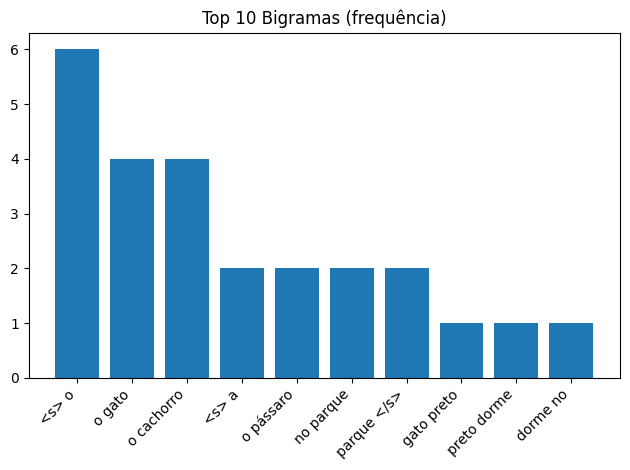

In [8]:

topk = 10
items = bigram_counts.most_common(topk)
labels = [" ".join(k) for k, _ in items]
values = [v for _, v in items]

plt.figure()
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=45, ha="right")
plt.title("Top 10 Bigramas (frequência)")
plt.tight_layout()
plt.show()



## 8) Desafios e Extensões

1. **Interpolação**: implemente um modelo interpolado $ \lambda_1 P_{uni} + \lambda_2 P_{bi} + \lambda_3 P_{tri} $.
2. **Kneser–Ney**: implemente suavização absoluta (discounting) e Kneser–Ney modificado.  
3. **OOV/UNK**: adicione um token `<unk>` para palavras raras.  
4. **Corpus próprio**: carregue seus textos (ex.: Fernando Pessoa) e compare perplexidade por domínio.  
5. **Avaliação cruzada**: separe treino/validação/teste e ajuste o hiperparâmetro de Laplace.

